In [17]:
import cv2
import numpy as np
import pandas as pd
from scipy.sparse import coo_array
import matplotlib.pyplot as plt
import seaborn as sns


(222, 225)


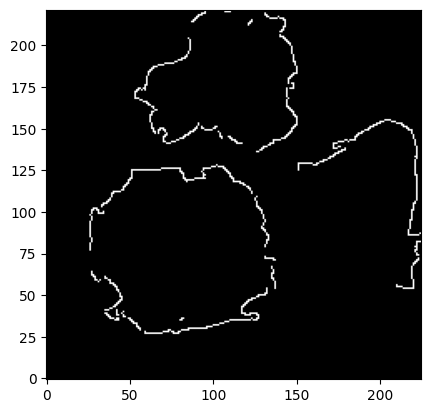

In [32]:
spacia_metadata = pd.read_csv('/syn2/zhaolian/3.JiLab/results/5.Steroseq/03.cellbin/step5.cellbin_4007_anno_metadata.txt',
                              sep="\t",dtype={'first_type': str})
spacia_metadata = spacia_metadata[spacia_metadata['spot_class']!= 'reject']
spacia_metadata.iloc[:3,]


_cols = spacia_metadata['x'].to_numpy()
_rows = spacia_metadata['y'].to_numpy()
_cnt = spacia_metadata['first_type'].astype(bool).astype(int).to_numpy()
cnt = coo_array((_cnt, (_rows//50, _cols//50*1)), shape=(max(_rows//50)+1, max(_cols//50)+1))
image = (cnt.toarray() * 255).astype(np.uint8)
# plt.imshow(image, cmap='gray')
success, buffer = cv2.imencode('.png', image)
image = cv2.imdecode(buffer, cv2.IMREAD_UNCHANGED)
blurred = cv2.GaussianBlur(image, (5, 5), 0)
edge = cv2.Canny(blurred, 480, 650)  
print(edge.shape)

# edge[200:223][80:140] = 255
## inside ThyM 
edge[180:210,100:140] = 0
edge[100:140,180:210] = 0
edge[125:150,195:215] = 0
## inside ThyM 
edge[155:180,70:110] = 0
edge[180:210,88:140] = 0
edge[200:215,125:140] = 0
edge[150:155,130:145] = 0
edge[150:155,130:145] = 0
## inside LvM 
edge[50:125,150:210] = 0
# edge[25:88,200:230] = 0

plt.imshow(edge, cmap='gray', origin='lower')

In [33]:
# 示例二维数组
arr = edge
# 获取非零元素的坐标
coords = np.argwhere(arr != 0)
df = pd.DataFrame(coords, columns=["Row", "Column"])
df['Row'] = df['Row']# * 50
df['Column'] = df['Column']# * 50
print(df)

max(spacia_metadata['y']/50)

      Row  Column
0      27      59
1      27      60
2      27      61
3      27      62
4      27      63
...   ...     ...
1024  220     109
1025  220     110
1026  221      95
1027  221     107
1028  221     110

[1029 rows x 2 columns]


221.24

In [34]:
distances_all = []
for i in range(0,len(spacia_metadata)):
    point = np.array([int(spacia_metadata.iloc[i]['y'])/50,int(spacia_metadata.iloc[i]['x'])/50])  
    other_points = coords
    distances = np.linalg.norm(other_points - point, axis=1)
    min_distance = float(np.min(distances))
    distances_all.append(min_distance)

spacia_metadata['distances'] = distances_all

In [45]:
custom_palette = {'0':"#FF6A6A",'1':"#00A087FF",'2':"#4DBBD5FF",'3':"#F39B7FFF",'4':"#FF8C00",'5':"#00CD00",'6':"#AB82FF",'7':"#DC0000FF",'8':"#7E6148FF"}

custom_palette = {"Epithelial-like":"#FF6A6A","Hybrid-state":"#FF8C00","Neuronal-like":"#4DBBD5FF",
                 "DC":"#1E90FF","Endothelial":"#8B4513","Fibroblast":"#708090","Granulosa":"#9370DB","Macrophage":"#B8860B",
             "Mast_cell":"#FF1493","Monocyte":"#20B2AA","Neutrophil":"#4682B4","NK":"#6A5ACD","Oocytes":"#228B22","Theca":"#FF4500"}

In [36]:
spacia_metadata.iloc[:3,]
spacia_metadata.to_csv("/syn2/zhaolian/3.JiLab/results/5.Steroseq/03.cellbin/distance_to_margin_4007.csv", index=False)

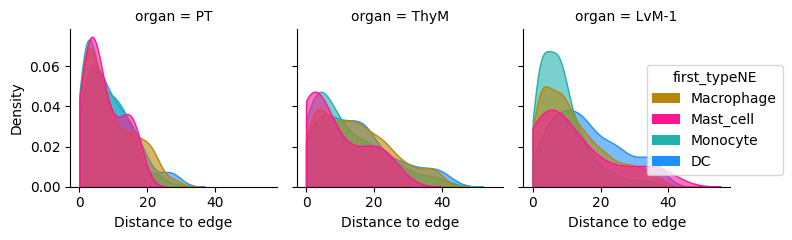

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 确保 first_type 是字符串
spacia_metadata["first_typeNE"] = spacia_metadata["first_typeNE"].astype(str)
# 筛选需要的 first_type 和 organ
# filtered_data = spacia_metadata[spacia_metadata["first_typeNE"].isin(["Epithelial-like","Hybrid-state","Neuronal-like"]) &
#     spacia_metadata["organ"].isin(['PT', 'ThyM', 'LvM-1'])]
filtered_data = spacia_metadata[spacia_metadata["first_typeNE"].isin(["Macrophage","Mast_cell","Monocyte","DC"]) &
    spacia_metadata["organ"].isin(['PT', 'ThyM', 'LvM-1'])]
# 创建 FacetGrid
g = sns.FacetGrid(data=filtered_data,col="organ", col_order=['PT', 'ThyM', 'LvM-1'],  # 确保顺序一致
    hue="first_typeNE",palette=custom_palette,height=2.5,aspect=1)
g.map_dataframe(sns.kdeplot,x="distances",fill=True,common_norm=False,alpha=0.6,clip=(0, None))
g.set_axis_labels("Distance to edge", "Density")
# 统一图例（手动创建）, 注意：必须从 FacetGrid 的图中手动提取 handles 和 labels
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=custom_palette[key], label=key) for key in ["Macrophage","Mast_cell","Monocyte","DC"]]
# 添加图例到 figure（不是 subplot）
g.fig.legend(handles=legend_elements,title='first_typeNE',loc='center right',bbox_to_anchor=(1.05, 0.5),borderaxespad=0.)
g.fig.tight_layout()
plt.savefig('/syn2/zhaolian/3.JiLab/results/5.Steroseq/03.cellbin/distance_to_margin_4007all.pdf', bbox_inches='tight')
plt.show()
